# SDR Lab: Noise Analysis and FM Reception
**Duration:** 2 hours  
**Date:** August 2024

**Getting started link:** https://pysdr.org/content/pluto.html

## Learning Objectives:
1. Understand complex signal representation in SDR
2. Analyze noise characteristics empirically
3. Implement FM demodulation
4. Work with time and frequency domain representations

In [15]:
# Install required packages
!pip install matplotlib numpy scipy sounddevice

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import numpy as np
import adi
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import resample
import sounddevice as sd
import time

# Configure PlutoSDR
sample_rate = 1e6 # Hz
center_freq = 400e6 # Hz (FM station frequency)
num_samps = 100000 # number of samples returned per call to rx()

sdr = adi.Pluto('ip:192.168.3.1')
sdr.gain_control_mode_chan0 = 'manual'
sdr.rx_hardwaregain_chan0 = 70.0 # dB
sdr.rx_lo = int(center_freq)
sdr.sample_rate = int(sample_rate)
sdr.rx_rf_bandwidth = int(sample_rate) # filter width, just set it to the same as sample rate for now
sdr.rx_buffer_size = num_samps

print("PlutoSDR configured successfully!")

PlutoSDR configured successfully!


# Part 1: Receiving and Analyzing Noise  

First, let's receive some samples and understand what we're getting from the SDR.

In [17]:
# Receive initial samples
samples = sdr.rx() # receive samples off Pluto
print(f"Received {len(samples)} samples")
print(f"First 10 samples: {samples[:10]}")
print(f"Sample data type: {samples.dtype}")

Received 100000 samples
First 10 samples: [  9.-27.j  15.-29.j  -1. +0.j -24.+12.j   2.-21.j   9.+10.j  -7. -6.j
  -9.-15.j  14.-10.j  -2.-18.j]
Sample data type: complex128


## Task 1: Collect More Samples  
Put the `samples = sdr.rx()` in a loop and collect more samples. Store them in a variable called `more_samples`. Collect at least 5 iterations worth of samples.

In [18]:
# Task 1: Your code here
# Collect multiple batches of samples
more_samples = []


# TODO: Write a loop to collect 5 batches of samples
for i in range(5):
    batch = sdr.rx()  # Receive a new batch
    more_samples.extend(batch)  # Add to list
    print(f"Batch {i+1}: Received {len(batch)} samples")

# Convert to numpy array for easier processing
more_samples = np.array(more_samples)
print(f"Total samples collected: {len(more_samples)}")

Batch 1: Received 100000 samples
Batch 2: Received 100000 samples
Batch 3: Received 100000 samples
Batch 4: Received 100000 samples
Batch 5: Received 100000 samples
Total samples collected: 500000


## Task 2: Scatter Plot Analysis  
Create a scatter plot of the real vs imaginary parts of your samples. This is called a "constellation diagram" in communications.

**Your task:** Plot np.real(more_samples) vs np.imag(more_samples) using plt.scatter(). Use only the first 10,000 samples for clarity.

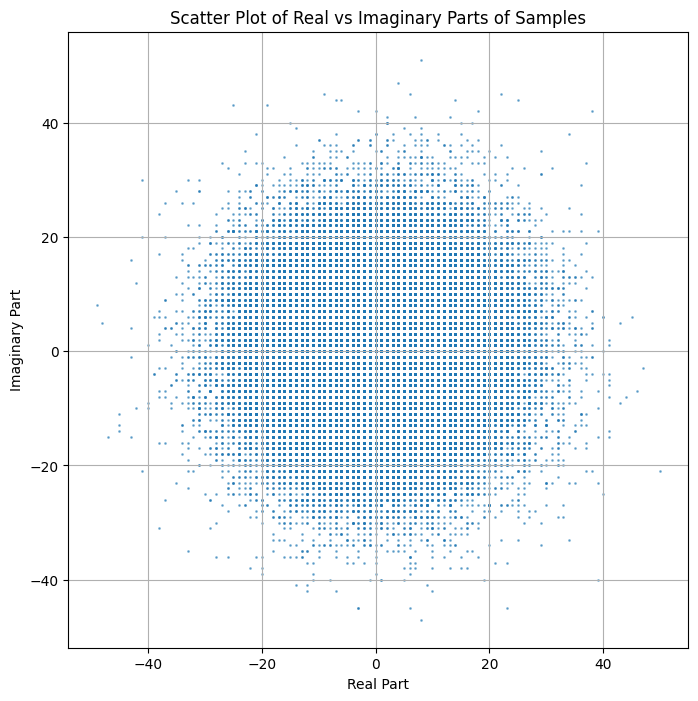

In [19]:
# Task 2: Create scatter plot here
# Extract real and imaginary parts
real_part = np.real(more_samples)
imag_part = np.imag(more_samples)
# TODO: Create scatter plot of real vs imaginary parts
# - Use plt.figure() to set the figure size to (8, 8)
# - Create a scatter plot of real_part vs imag_part (first 100000 samples)
# - Set appropriate title, xlabel, ylabel
# - Add grid and ensure equal axis scaling
# - Display the plot
N = min(100000, len(more_samples))

plt.figure(figsize=(8, 8))  # Set figure size

plt.scatter(real_part[:N], imag_part[:N], s=1, alpha=0.5)  # s=1 makes points small, alpha=0.5 for slight transparency

plt.title("Scatter Plot of Real vs Imaginary Parts of Samples")
plt.xlabel("Real Part")
plt.ylabel("Imaginary Part")
plt.grid(True)
plt.axis('equal')  # Equal scaling on both axes

plt.show()

## Task 3: Histogram Analysis 
Plot histograms of the real and imaginary parts separately. Then analyze their statistical distributions.

**Your task:**
1. Create histograms of real_part and imag_part using plt.hist()
2. Fit Gaussian distributions using stats.norm.fit()
3. Overlay the fitted distributions on your histograms

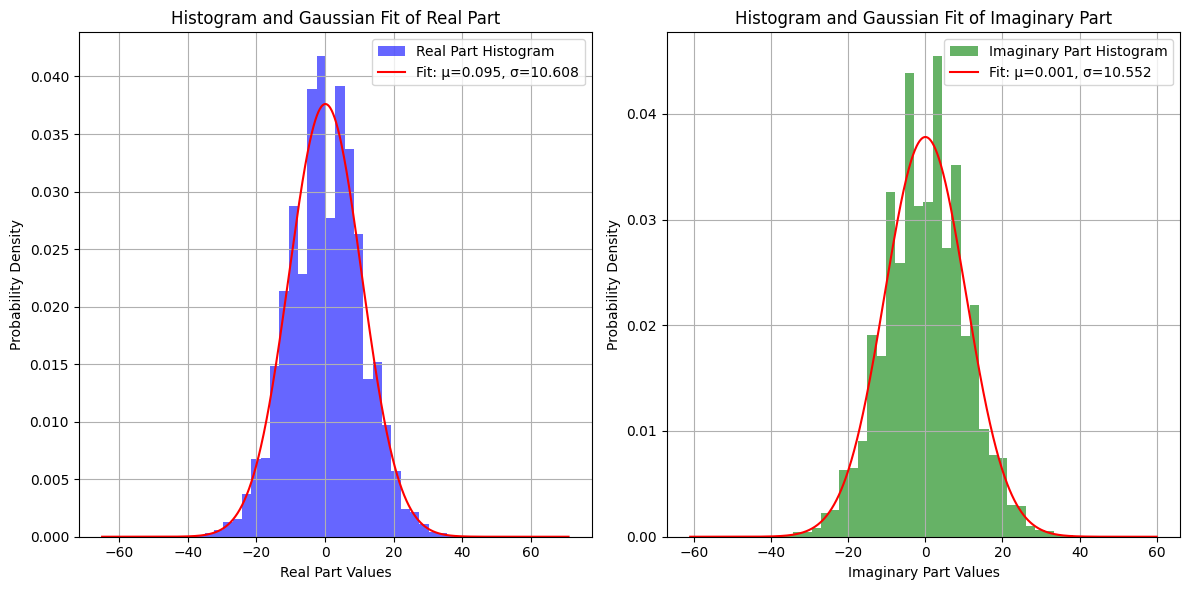

In [20]:
# Task 3: Histogram analysis with distribution fitting
# Extract real and imaginary parts
real_part = np.real(more_samples)
imag_part = np.imag(more_samples)

# TODO: Create side-by-side histograms for real and imaginary parts
# Hint: Use plt.figure() with figsize=(12, 6) and plt.subplot(1, 2, 1) for left plot


# TODO: Fit Gaussian distributions to both real and imaginary parts
# Hint: Use stats.norm.fit(data) which returns (mu, sigma)


# TODO: Plot the fitted Gaussian curves over the histograms
# Hint: Create x values using np.linspace() and calculate PDF using stats.norm.pdf()
# Add the curves to both subplots with appropriate labels showing mu and sigma values

# Create figure and subplots
plt.figure(figsize=(12, 6))

# Left subplot for Real part
plt.subplot(1, 2, 1)
count_real, bins_real, _ = plt.hist(real_part, bins=50, density=True, alpha=0.6, color='b', label='Real Part Histogram')

# Fit Gaussian distribution to real part
mu_real, sigma_real = stats.norm.fit(real_part)

# Generate x values for PDF
x_real = np.linspace(bins_real[0], bins_real[-1], 1000)
pdf_real = stats.norm.pdf(x_real, mu_real, sigma_real)

# Plot fitted Gaussian PDF
plt.plot(x_real, pdf_real, 'r-', label=f'Fit: μ={mu_real:.3f}, σ={sigma_real:.3f}')
plt.title('Histogram and Gaussian Fit of Real Part')
plt.xlabel('Real Part Values')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)

# Right subplot for Imaginary part
plt.subplot(1, 2, 2)
count_imag, bins_imag, _ = plt.hist(imag_part, bins=50, density=True, alpha=0.6, color='g', label='Imaginary Part Histogram')

# Fit Gaussian distribution to imaginary part
mu_imag, sigma_imag = stats.norm.fit(imag_part)

# Generate x values for PDF
x_imag = np.linspace(bins_imag[0], bins_imag[-1], 1000)
pdf_imag = stats.norm.pdf(x_imag, mu_imag, sigma_imag)

# Plot fitted Gaussian PDF
plt.plot(x_imag, pdf_imag, 'r-', label=f'Fit: μ={mu_imag:.3f}, σ={sigma_imag:.3f}')
plt.title('Histogram and Gaussian Fit of Imaginary Part')
plt.xlabel('Imaginary Part Values')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Task 4: Analysis Questions (10 minutes)
Based on your plots and statistical analysis above, answer these questions:

1. **What distribution do the real and imaginary parts follow?**
   - Looking at the histograms and statistical fits, what can you conclude?

2. **What does the constellation diagram tell us?**
   - Is there any structure or is it random?

3. **Are the real and imaginary parts correlated?**
   - Do they appear to be independent?

**Expected observations:**
- The data should show characteristics of **complex Gaussian noise** (AWGN - Additive White Gaussian Noise)
- Both I and Q components should be approximately Gaussian with similar variances
- The constellation should appear as a circular cloud centered around the origin
- This is what we expect when receiving thermal noise

## Task 5: Frequency Analysis (5 minutes)
Try different frequencies to find where you receive only noise vs actual signals.

**Your task:** Test these frequencies and compare their power spectra:
- 88 MHz (Low end of FM band)
- 95 MHz (Mid FM band)
- 103 MHz (Your original frequency)
- 108 MHz (High end of FM band)
- 400 MHz (Empty spectrum area)

Frequency: 88 MHz, Max Power: 22.0 dBm/Hz, Avg Noise Floor: -7.6 dBm/Hz
Frequency: 95 MHz, Max Power: 22.0 dBm/Hz, Avg Noise Floor: -8.2 dBm/Hz
Frequency: 103 MHz, Max Power: 21.8 dBm/Hz, Avg Noise Floor: -8.2 dBm/Hz
Frequency: 108 MHz, Max Power: 17.3 dBm/Hz, Avg Noise Floor: -3.2 dBm/Hz
Frequency: 400 MHz, Max Power: 23.1 dBm/Hz, Avg Noise Floor: -6.8 dBm/Hz


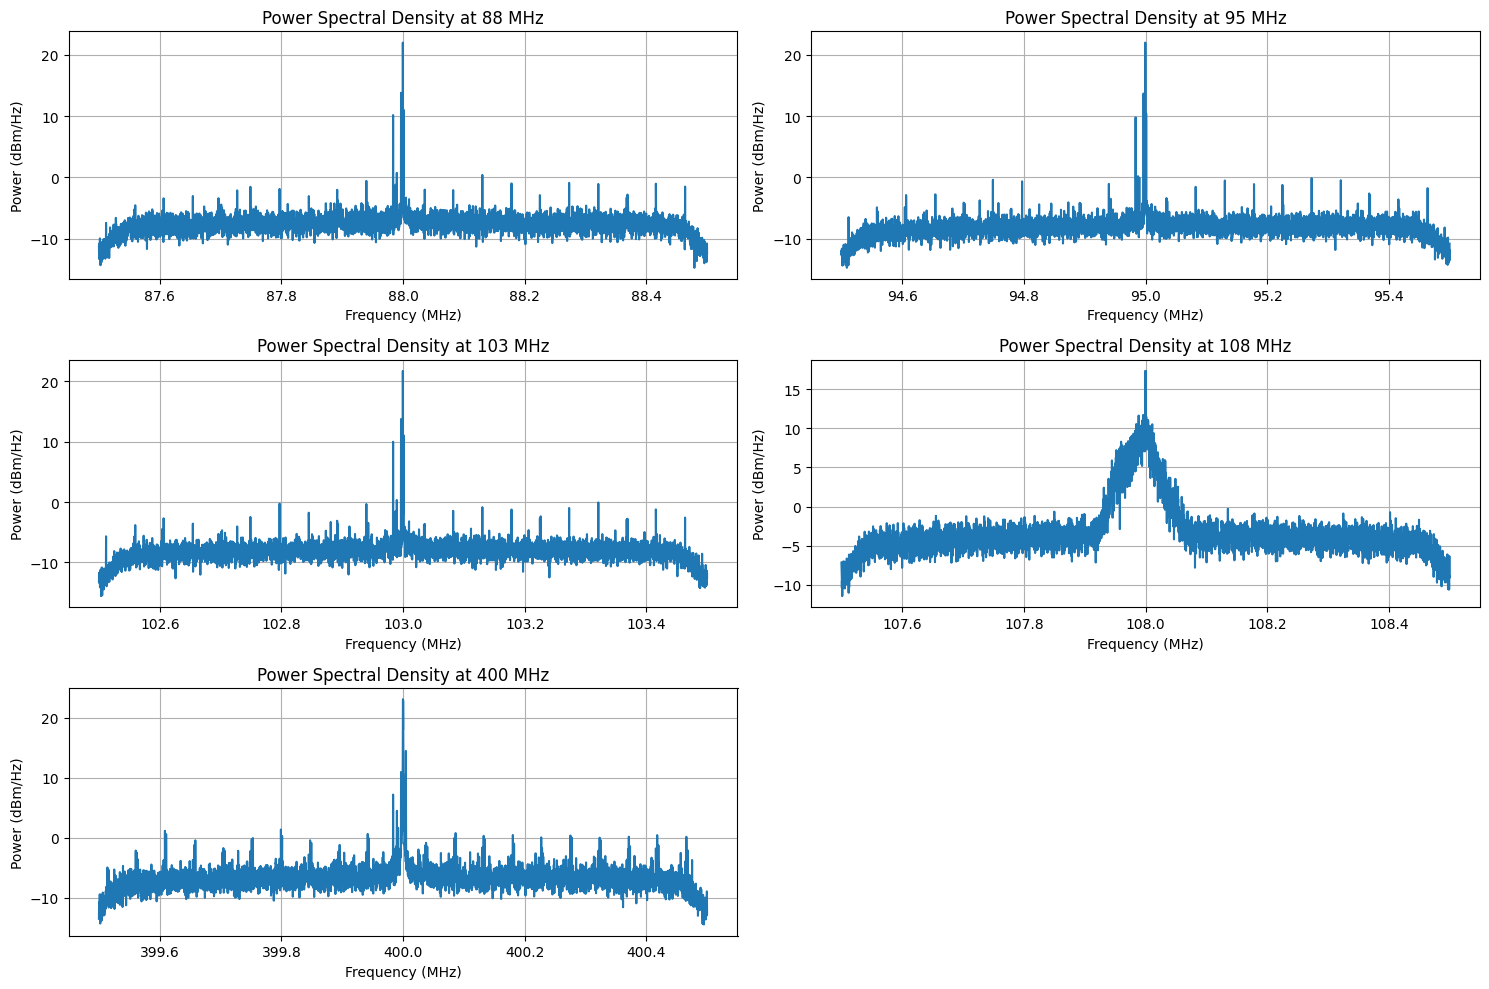

Reset to original frequency: 400.0 MHz

Note: Using Welch's method for better PSD estimation with averaging and windowing


In [21]:
# Task 4: Test different frequencies
test_frequencies = [88e6, 95e6, 103e6, 108e6, 400e6]

# Import scipy for PSD functions
from scipy import signal

# Create figure for subplots
plt.figure(figsize=(15, 10))

# Loop through each frequency and analyze the signal
for i, freq in enumerate(test_frequencies):
    # Set the SDR receiver frequency
    sdr.rx_lo = int(freq)
    
    # Collect samples
    samples = sdr.rx()
    
    # Calculate PSD using Welch's method (much better than manual FFT)
    freqs_psd, psd = signal.welch(samples, fs=sample_rate, 
                                  window='hann', nperseg=8192, 
                                  return_onesided=False, scaling='density')
    
    # Shift to center the spectrum
    freqs_shifted = np.fft.fftshift(freqs_psd)
    psd_shifted = np.fft.fftshift(psd)
    
    # Convert to actual frequencies (add center frequency)
    actual_freqs = freqs_shifted + freq
    
    # Convert to dBm/Hz
    psd_dbm = 10 * np.log10(psd_shifted + 1e-20) + 30
    
    # Create subplot
    plt.subplot(3, 2, i+1)
    plt.plot(actual_freqs/1e6, psd_dbm)
    plt.title(f'Power Spectral Density at {freq/1e6:.0f} MHz')
    plt.xlabel('Frequency (MHz)')
    plt.ylabel('Power (dBm/Hz)')
    plt.grid(True)
     
    # Print statistics
    max_power_dbm = np.max(psd_dbm)
    avg_noise_floor = np.mean(psd_dbm)
    print(f"Frequency: {freq/1e6:.0f} MHz, Max Power: {max_power_dbm:.1f} dBm/Hz, Avg Noise Floor: {avg_noise_floor:.1f} dBm/Hz")

plt.tight_layout()
plt.show()

# Reset to original frequency
sdr.rx_lo = int(center_freq)
print(f"Reset to original frequency: {center_freq/1e6:.1f} MHz")
print("\nNote: Using Welch's method for better PSD estimation with averaging and windowing")

# Part 2: FM Radio Reception and Demodulation (75 minutes)

Now let's implement FM demodulation to listen to actual radio broadcasts.

## FM Demodulation Theory:
- FM encodes information in the **frequency** of the carrier
- To demodulate: extract the instantaneous frequency
- Method: Take the phase derivative of the complex signal
- Steps: `phase → differentiate → audio`

## Setup Audio System
First, let's set up the audio processing components.

In [3]:
# Test audio system
print("Available audio devices:")
print(sd.query_devices())

# Test with a simple tone
print("\nTesting audio system with 1kHz tone for 1 second...")
test_tone = np.sin(2 * np.pi * 1000 * np.linspace(0, 1, 44100))
try:
    sd.play(test_tone, samplerate=44100)
    sd.wait()  # Wait until the sound finishes playing
    print("Audio test successful!")
except Exception as e:
    print(f"Audio test failed: {e}")
    print("You may not hear audio, but demodulation analysis will still work.")

Available audio devices:
   0 HDA Intel PCH: ALC256 Analog (hw:0,0), ALSA (2 in, 2 out)
   1 HDA Intel PCH: HDMI 0 (hw:0,3), ALSA (0 in, 8 out)
   2 HDA Intel PCH: HDMI 1 (hw:0,7), ALSA (0 in, 8 out)
   3 HDA Intel PCH: HDMI 2 (hw:0,8), ALSA (0 in, 8 out)
   4 HDA Intel PCH: HDMI 3 (hw:0,9), ALSA (0 in, 8 out)
   5 HDA Intel PCH: HDMI 4 (hw:0,10), ALSA (0 in, 8 out)
   6 HDA Intel PCH: HDMI 5 (hw:0,11), ALSA (0 in, 8 out)
   7 HDA Intel PCH: HDMI 6 (hw:0,12), ALSA (0 in, 8 out)
   8 HDA Intel PCH: HDMI 7 (hw:0,13), ALSA (0 in, 8 out)
   9 HDA Intel PCH: HDMI 8 (hw:0,14), ALSA (0 in, 8 out)
  10 HDA Intel PCH: HDMI 9 (hw:0,15), ALSA (0 in, 8 out)
  11 HDA Intel PCH: HDMI 10 (hw:0,16), ALSA (0 in, 8 out)
  12 HDA Intel PCH: HDMI 11 (hw:0,17), ALSA (0 in, 8 out)
  13 sysdefault, ALSA (128 in, 128 out)
  14 front, ALSA (0 in, 2 out)
  15 surround40, ALSA (0 in, 2 out)
  16 surround51, ALSA (0 in, 2 out)
  17 surround71, ALSA (0 in, 2 out)
  18 hdmi, ALSA (0 in, 8 out)
  19 samplerate, ALSA

## Task 6: Implement FM Demodulation (30 minutes)
Let's implement the missing pieces of the FM demodulator step by step.

**Your task:** Complete the FM demodulation algorithm:
1. Extract instantaneous phase using `np.angle()`
2. Unwrap phase discontinuities using `np.unwrap()`
3. Take derivative using `np.diff()`

Receiving FM samples...
Received 100000 samples

Step 1: Extracting instantaneous phase...
Phase range: -3.117 to 3.142 radians

Step 2: Unwrapping phase...
Unwrapped phase range: -28.132 to 1119.656 radians

Step 3: Computing derivative (instantaneous frequency)...
Instantaneous frequency in Hz: -44000000.0 to 44000000.0 Hz


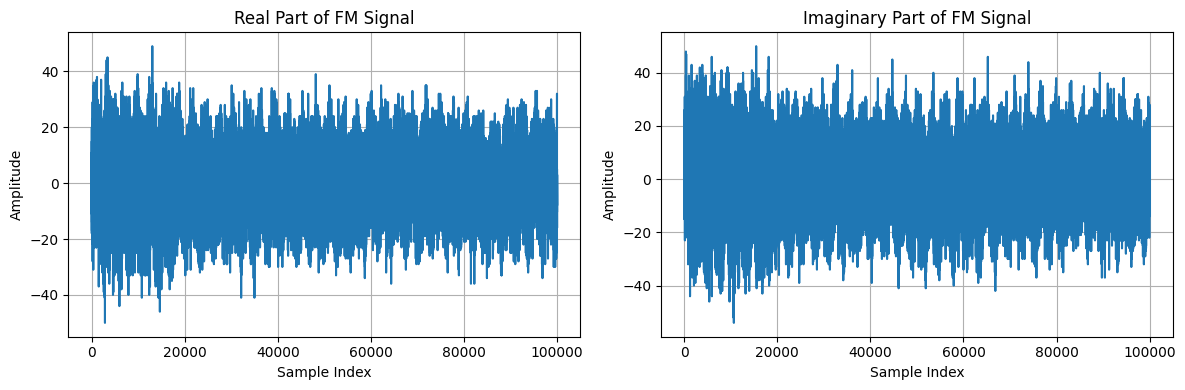

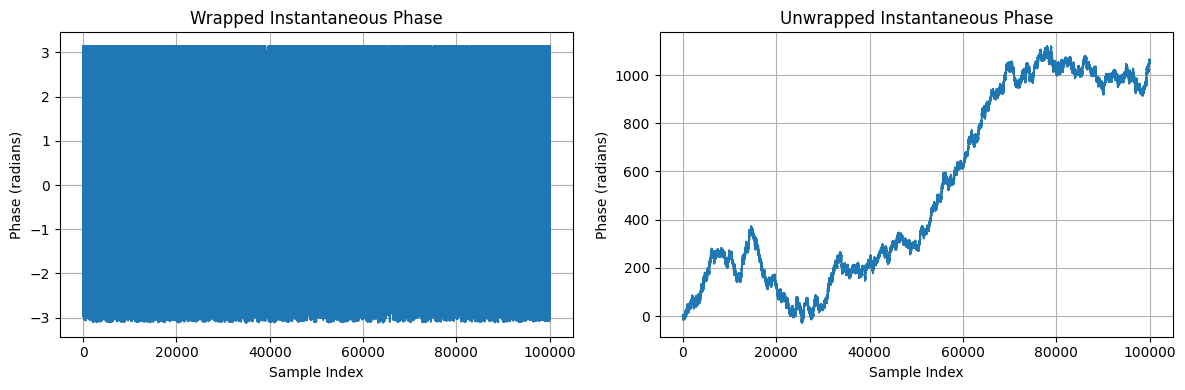

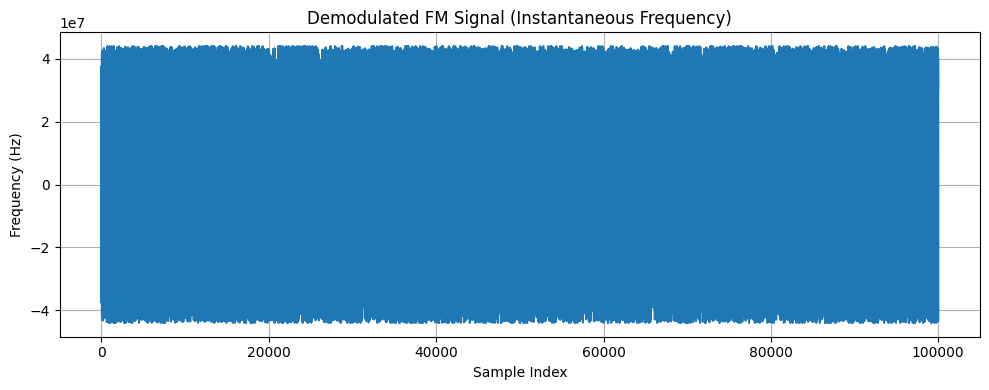

In [23]:
# Task 5: Step-by-step FM demodulation implementation
# First, let's receive some samples at FM frequency
print("Receiving FM samples...")
fm_samples = sdr.rx()
print(f"Received {len(fm_samples)} samples")

sample_rate = 88e6

# Step 1: Extract the instantaneous phase
print("\nStep 1: Extracting instantaneous phase...")
# TODO: Complete this line - extract phase using np.angle()
instantaneous_phase = np.angle(fm_samples)

print(f"Phase range: {np.min(instantaneous_phase):.3f} to {np.max(instantaneous_phase):.3f} radians")

# Step 2: Unwrap the phase to handle discontinuities
print("\nStep 2: Unwrapping phase...")
# TODO: Complete this line - unwrap phase using np.unwrap()
unwrapped_phase = np.unwrap(instantaneous_phase)

print(f"Unwrapped phase range: {np.min(unwrapped_phase):.3f} to {np.max(unwrapped_phase):.3f} radians")

# Step 3: Take the derivative to get instantaneous frequency
print("\nStep 3: Computing derivative (instantaneous frequency)...")
# TODO: Complete this line - take the derivative using np.diff()
instantaneous_frequency = np.diff(unwrapped_phase)

# Convert from radians per sample to Hz
instantaneous_message = instantaneous_frequency * sample_rate / (2 * np.pi)
print(f"Instantaneous frequency in Hz: {np.min(instantaneous_message):.1f} to {np.max(instantaneous_message):.1f} Hz")

# TODO: Create plots to visualize each step of the process
# Plot 1: Original signal (real and imaginary parts)
# - Create figure with size (12, 4)
# - Use 1x2 subplots
# - Left: plot real part, Right: plot imaginary part
# - Add appropriate titles and labels
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(np.real(fm_samples))
plt.title("Real Part of FM Signal")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(np.imag(fm_samples))
plt.title("Imaginary Part of FM Signal")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

# Plot 2: Instantaneous phase (wrapped and unwrapped)  
# - Create figure with size (12, 4)
# - Use 1x2 subplots
# - Left: plot wrapped phase, Right: plot unwrapped phase
# - Add appropriate titles and labels
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(instantaneous_phase)
plt.title("Wrapped Instantaneous Phase")
plt.xlabel("Sample Index")
plt.ylabel("Phase (radians)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(unwrapped_phase)
plt.title("Unwrapped Instantaneous Phase")
plt.xlabel("Sample Index")
plt.ylabel("Phase (radians)")
plt.grid(True)

plt.tight_layout()
plt.show()

# Plot 3: Demodulated signal (instantaneous frequency)
# - Create figure with size (10, 4) 
# - Plot the instantaneous_message
# - Add title, labels, and grid
plt.figure(figsize=(10, 4))
plt.plot(instantaneous_message)
plt.title("Demodulated FM Signal (Instantaneous Frequency)")
plt.xlabel("Sample Index")
plt.ylabel("Frequency (Hz)")
plt.grid(True)
plt.tight_layout()
plt.show()

## Task 7: Audio Processing and Playback (25 minutes)
Now let's process the demodulated signal for audio playback.

**Your task:**
1. Remove DC component from the demodulated signal
   
3. Resample from 1 MHz to 44.1 kHz using `resample()`
4. Normalize the signal for audio playback
5. Play the audio using `sd.play()`

In [36]:
print("\nStep 1: Removing DC component...")
instantaneous_message_dc_removed = instantaneous_message - np.mean(instantaneous_message)

print("\nStep 2: Resampling to 44.1 kHz...")
original_rate = 1e6  # or set this to your actual post-demodulation rate
target_rate = 44100

num_samples = int(len(instantaneous_message_dc_removed) * target_rate / original_rate)
audio_resampled = resample(instantaneous_message_dc_removed, num_samples)

print(f"Resampled from {len(instantaneous_message_dc_removed)} to {len(audio_resampled)} samples")

print("\nStep 3: Normalizing audio...")
if np.max(np.abs(audio_resampled)) > 0:
    audio_normalized = audio_resampled / np.max(np.abs(audio_resampled))
else:
    audio_normalized = audio_resampled

print("\nStep 4: Playing audio...")
sd.play(audio_normalized, samplerate=target_rate)
sd.wait()

print("Audio playback complete.")



Step 1: Removing DC component...

Step 2: Resampling to 44.1 kHz...
Resampled from 99999 to 4409 samples

Step 3: Normalizing audio...

Step 4: Playing audio...
Audio playback complete.


In [4]:
# Configure PlutoSDR
sample_rate = 1e6 # Hz
center_freq = 103e6 # Hz (FM station frequency)
num_samps = 100000 # number of samples returned per call to rx()

sdr = adi.Pluto('ip:192.168.3.1')
sdr.gain_control_mode_chan0 = 'manual'
sdr.rx_hardwaregain_chan0 = 70.0 # dB
sdr.rx_lo = int(center_freq)
sdr.sample_rate = int(sample_rate)
sdr.rx_rf_bandwidth = int(sample_rate) # filter width, just set it to the same as sample rate for now
sdr.rx_buffer_size = num_samps

print("PlutoSDR configured successfully!")

PlutoSDR configured successfully!


## Task 8: Real-time FM Demodulation (20 minutes)
Let's create a real-time version that continuously demodulates FM radio.

**Your task:** Complete the FM demodulation function and run it in a loop for real-time processing.

In [6]:
import numpy as np
from scipy.signal import resample
import sounddevice as sd
import time

print("Starting real-time FM demodulation...")
print("This will run for 30 seconds. Press Ctrl+C to stop early.")

def fm_demodulation_function(samples, last_phase):
    """Complete the FM demodulation pipeline for one chunk"""
    # Step 1: Extract phase
    phase = np.angle(samples)

    # Step 2: Unwrap phase with continuity from last chunk
    phase_with_last = np.concatenate(([last_phase], phase))
    unwrapped_phase = np.unwrap(phase_with_last)

    # Remove the first element (corresponding to last_phase)
    unwrapped_phase = unwrapped_phase[1:]

    # Step 3: Differentiate
    inst_message = np.diff(np.concatenate(([unwrapped_phase[0]], unwrapped_phase)))

    # Step 4: Convert radians/sample to Hz
    inst_message_hz = inst_message * (sample_rate / (2 * np.pi))

    return inst_message_hz, unwrapped_phase[-1]

def audio_processing_function(demod_signal, target_length):
    """Resample and normalize for audio playback"""
    # Step 1: Resample to audio rate
    audio_signal = resample(demod_signal, target_length)

    # Step 2: Normalize
    if np.max(np.abs(audio_signal)) > 0:
        normalized_audio = 1 * (audio_signal / np.max(np.abs(audio_signal)))
    else:
        normalized_audio = audio_signal

    return normalized_audio

# Real-time processing loop
try:
    start_time = time.time()
    chunk_count = 0
    playback_sample_rate = 44100
    
    # Track last phase to ensure continuity
    last_sample_phase = 0.0

    while time.time() - start_time < 30:  # Run for 30 seconds
        # Receive samples from SDR
        samples = sdr.rx()  # This should return complex baseband samples

        # Demodulate chunk
        demodulated, last_sample_phase = fm_demodulation_function(samples, last_sample_phase)

        # Compute target audio length for resampling
        audio_length = int(len(demodulated) * playback_sample_rate / sample_rate)
        if audio_length == 0:
            continue

        # Process for audio playback
        audio_chunk = audio_processing_function(demodulated, audio_length) 

        # Play audio chunk (non-blocking)
        try:
            sd.play(audio_chunk, samplerate=playback_sample_rate, blocking=False)
            chunk_count += 1

            # Show progress every 10 chunks
            if chunk_count % 10 == 0:
                print(f"Processed {chunk_count} chunks, elapsed: {time.time() - start_time:.1f}s")

        except Exception as e:
            print(f"Audio error: {e}")

except KeyboardInterrupt:
    print("\nStopped by user")
except Exception as e:
    print(f"Error in real-time processing: {e}")
finally:
    sd.stop()

print(f"\nReal-time FM demodulation completed! Processed {chunk_count} chunks.")


Starting real-time FM demodulation...
This will run for 30 seconds. Press Ctrl+C to stop early.
Processed 10 chunks, elapsed: 0.7s
Processed 20 chunks, elapsed: 1.7s
Processed 30 chunks, elapsed: 2.7s
Processed 40 chunks, elapsed: 3.7s
Processed 50 chunks, elapsed: 4.7s
Processed 60 chunks, elapsed: 5.7s
Processed 70 chunks, elapsed: 6.7s
Processed 80 chunks, elapsed: 7.7s
Processed 90 chunks, elapsed: 8.7s
Processed 100 chunks, elapsed: 9.7s
Processed 110 chunks, elapsed: 10.7s
Processed 120 chunks, elapsed: 11.7s
Processed 130 chunks, elapsed: 12.7s
Processed 140 chunks, elapsed: 13.7s
Processed 150 chunks, elapsed: 14.7s
Processed 160 chunks, elapsed: 15.7s
Processed 170 chunks, elapsed: 16.7s
Processed 180 chunks, elapsed: 17.7s
Processed 190 chunks, elapsed: 18.7s
Processed 200 chunks, elapsed: 19.7s
Processed 210 chunks, elapsed: 20.7s
Processed 220 chunks, elapsed: 21.7s
Processed 230 chunks, elapsed: 22.7s
Processed 240 chunks, elapsed: 23.7s
Processed 250 chunks, elapsed: 24.7

# Final Analysis Questions (10 minutes)

Based on your experiments, discuss the following:

## 1. Noise Characteristics
- What type of noise did you observe in the empty frequency bands?
- How well did the Gaussian distribution fit your noise samples?
- Why do you think both I and Q components have similar statistical properties?

## 2. FM Demodulation
- Which step in the FM demodulation process was most critical?
- What happened when you didn't unwrap the phase?
- How did the audio quality change with different processing parameters?

## 3. Practical Considerations
- What were the main challenges in real-time processing?
- How could you improve the audio quality further?
- What other types of signals could you demodulate with similar techniques?

## 4. System Understanding
- How does the SDR sample rate affect your ability to demodulate signals?
- What is the relationship between RF bandwidth and audio quality?
- Why do we need to downsample the demodulated signal for audio playback?

**Write your observations and answers below:**

_[Space for student responses]_

# Lab Conclusion

Congratulations! You have successfully:

✅ **Analyzed noise characteristics** and empirically derived statistical distributions  
✅ **Implemented FM demodulation** from first principles  
✅ **Processed and played back** demodulated audio  
✅ **Created a real-time** FM radio receiver  
✅ **Understood the relationship** between RF signals and digital processing  

## Key Takeaways:
- SDR systems work with complex I/Q samples that represent RF signals
- Noise in RF systems typically follows Gaussian distributions
- FM demodulation involves phase extraction and differentiation
- Real-time signal processing requires careful attention to timing and buffering
- Digital signal processing enables flexible, software-defined radio systems

## Next Steps:
- Explore other modulation schemes (AM, SSB, digital modes)
- Learn about advanced filtering and signal processing techniques
- Study software-defined radio architecture and implementation
- Investigate wireless communication protocols and standards

**Great job completing this SDR lab!**

# **Additional Tasks**

## **Task 7: Frequency Band Scanner**
Create a frequency scanner that sweeps across FM (88-108 MHz), WiFi (2.4 GHz), cellular (800-900 MHz), and GPS (1.575 GHz) bands. Compare your measured signal strengths with the official frequency allocations. Identify which bands show the most activity in your location and determine if the signals match expected services (FM radio stations, WiFi networks, cell towers). Plot the results and annotate any strong signals you detect.

## **Task 8: FM Signal Bandwidth Analysis**
Tune to a strong FM radio station and measure its actual occupied bandwidth using spectral analysis. Compare this measured bandwidth with the theoretical FM channel spacing (200 kHz in most countries). Analyze whether the station is using the full allocated bandwidth or if there's spectrum spillover into adjacent channels. Investigate how the bandwidth changes with different modulation (music vs voice) and document any differences between what you measure versus the regulatory specifications.